# 🥊 YOLOv8 Model Showdown: Custom Trained vs. Pretrained Model
### Automated Benchmark & Performance Evaluation for Real-Time Traffic Violation Detection

This notebook conducts a deep, rigorous benchmark comparing two object detection models:
1. **Model A (Custom Trained)**: `saved_models/best.pt`
   - Fine-tuned on the specialized `HelmetDataset` (Indian traffic scenarios, multi-rider conditions).
2. **Model B (Pretrained Model)**: `saved_models/helmet_detection_model.pt`
   - Off-the-shelf YOLOv8 safety helmet detection model pretrained on large helmet datasets.

---

### 📊 Benchmark Dimensions
1. **Model Architecture & Physical Profile** (File size, parameter count, target classes)
2. **Inference Latency & Throughput** (Cold start vs Warm run, FPS on GPU / CPU)
3. **Quantitative Test Accuracy (77 unseen test images)**:
   - Overall: mAP@50, mAP@50-95, Mean Precision, Mean Recall, F1-Score
   - Per-Class Breakdown: `With Helmet` (Compliant) vs. `Without Helmet` (Violator)
4. **Qualitative Side-by-Side Visual Inspection** (Visualizing edge cases, multiple riders, crowded streets)
5. **Scorecard & Definitive Verdict** (Automated 100-point decision matrix determining the best deployment choice)


In [20]:
import os
import cv2
import time
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# Set random seeds for reproducible visual sampling
random.seed(42)
np.random.seed(42)

# Plot styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# Hardware & Directory Setup
BASE_DIR = Path.cwd().resolve()
CUSTOM_MODEL_PATH = BASE_DIR / "saved_models" / "best.pt"
PRETRAINED_MODEL_PATH = BASE_DIR / "saved_models" / "helmet_detection_model.pt"
DATA_YAML = BASE_DIR / "HelmetDataset" / "data.yaml"
TEST_IMG_DIR = BASE_DIR / "HelmetDataset" / "test" / "images"

DEVICE = 0 if torch.cuda.is_available() else "cpu"
DEVICE_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

print("=" * 65)
print("⚙️  BENCHMARK ENVIRONMENT")
print("=" * 65)
print(f"Compute Device        : {DEVICE_NAME}")
print(f"Custom Model Weights  : {CUSTOM_MODEL_PATH.name} ({'✅ Found' if CUSTOM_MODEL_PATH.exists() else '❌ Missing'})")
print(f"Pretrained Weights    : {PRETRAINED_MODEL_PATH.name} ({'✅ Found' if PRETRAINED_MODEL_PATH.exists() else '❌ Missing'})")
print(f"Dataset Config        : {DATA_YAML.name} ({'✅ Found' if DATA_YAML.exists() else '❌ Missing'})")
print(f"Test Images Count     : {len(list(TEST_IMG_DIR.glob('*.*')))} images in test set")
print("=" * 65)


⚙️  BENCHMARK ENVIRONMENT
Compute Device        : NVIDIA GeForce RTX 4050 Laptop GPU
Custom Model Weights  : best.pt (✅ Found)
Pretrained Weights    : helmet_detection_model.pt (✅ Found)
Dataset Config        : data.yaml (✅ Found)
Test Images Count     : 77 images in test set


## 🔍 Step 1: Model Architecture & Physical Profile
Before running validation, we inspect the physical characteristics of both models:
- Weights file size on disk (MB)
- Neural network parameter count (Total & Trainable)
- Target class taxonomy and detection tasks


In [21]:
# 1. Load Both Models
print("📦 Loading models into memory...")
model_custom = YOLO(str(CUSTOM_MODEL_PATH))
model_pretrained = YOLO(str(PRETRAINED_MODEL_PATH))
print("✅ Both models loaded successfully.")

# 2. Extract Specifications
def get_model_specs(model, model_path, label):
    file_size_mb = model_path.stat().st_size / (1024 * 1024)
    total_params = sum(p.numel() for p in model.model.parameters())
    trainable_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
    classes = [str(c).strip() for c in model.names.values()]
    task = getattr(model, 'task', 'detect')
    
    return {
        "Model": label,
        "Filename": model_path.name,
        "File Size (MB)": round(file_size_mb, 2),
        "Total Parameters": f"{total_params:,}",
        "Trainable Params": f"{trainable_params:,}",
        "Task": task,
        "Classes Count": len(classes),
        "Classes": ", ".join(classes)
    }

specs_data = [
    get_model_specs(model_custom, CUSTOM_MODEL_PATH, "Model A: Custom Trained"),
    get_model_specs(model_pretrained, PRETRAINED_MODEL_PATH, "Model B: Pretrained")
]

df_specs = pd.DataFrame(specs_data)
display(df_specs.set_index("Model"))


📦 Loading models into memory...
✅ Both models loaded successfully.


,Filename,File Size (MB),Total Parameters,Trainable Params,Task,Classes Count,Classes
Model,,,,,,,
Model A: Custom Trained,best.pt,5.95,"3,011,238",0,detect,2,"With Helmet, Without Helmet"
Model B: Pretrained,helmet_detection_model.pt,5.96,"3,011,238",0,detect,2,"With helmet, Without helmet"


## ⚡ Step 2: Real-Time Inference Speed & Latency Benchmark
In automated traffic enforcement, real-time throughput (>30 FPS) is crucial to avoid video lag or missed frames.
We evaluate:
- **Warmup Phase**: 10 runs to initialize CUDA pipelines and GPU kernels.
- **Latency (ms)**: Average time per frame across 50 iterations.
- **Throughput (FPS)**: Processing rate in Frames Per Second.


⏱️ Measuring Model A (Custom Trained) inference speed...
⏱️ Measuring Model B (Pretrained) inference speed...


,Latency (ms),Jitter / Std (ms),Throughput (FPS),Real-Time Feasible (>=30 FPS)
Model,,,,
Model A (Custom Trained),11.80,3.06,84.7,✅ Yes
Model B (Pretrained),10.97,3.20,91.2,✅ Yes


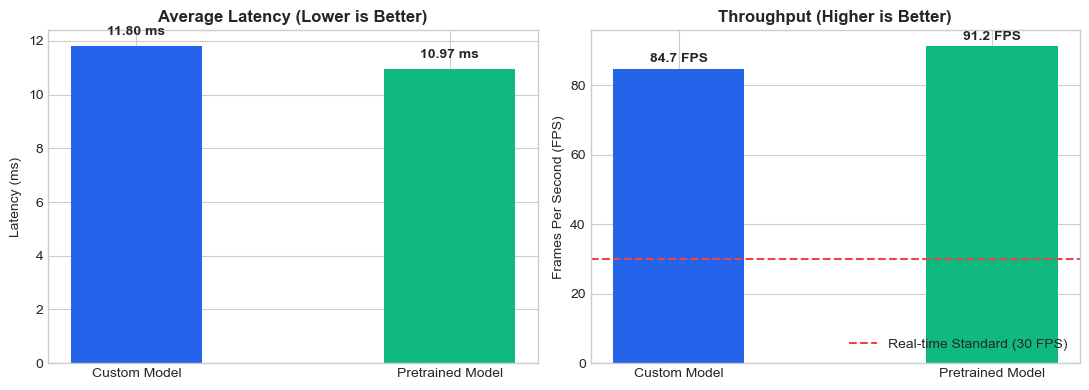

In [22]:
def benchmark_speed(model, test_dir, num_warmup=10, num_iters=50):
    images = list(test_dir.glob("*.jpg")) + list(test_dir.glob("*.png"))
    if not images:
        raise ValueError("No test images found for latency benchmark.")
    
    sample_imgs = [cv2.imread(str(random.choice(images))) for _ in range(num_iters)]
    
    # Warmup
    for i in range(num_warmup):
        _ = model.predict(sample_imgs[i % len(sample_imgs)], device=DEVICE, verbose=False)
        
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        
    latencies = []
    for img in sample_imgs:
        t0 = time.perf_counter()
        _ = model.predict(img, device=DEVICE, verbose=False)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        latencies.append((t1 - t0) * 1000.0)
        
    latencies = np.array(latencies)
    avg_lat = np.mean(latencies)
    std_lat = np.std(latencies)
    fps = 1000.0 / avg_lat
    
    return avg_lat, std_lat, fps

print("⏱️ Measuring Model A (Custom Trained) inference speed...")
cust_lat, cust_std, cust_fps = benchmark_speed(model_custom, TEST_IMG_DIR)

print("⏱️ Measuring Model B (Pretrained) inference speed...")
pre_lat, pre_std, pre_fps = benchmark_speed(model_pretrained, TEST_IMG_DIR)

df_speed = pd.DataFrame([
    {
        "Model": "Model A (Custom Trained)",
        "Latency (ms)": round(cust_lat, 2),
        "Jitter / Std (ms)": round(cust_std, 2),
        "Throughput (FPS)": round(cust_fps, 1),
        "Real-Time Feasible (>=30 FPS)": "✅ Yes" if cust_fps >= 30 else "⚠️ Borderline"
    },
    {
        "Model": "Model B (Pretrained)",
        "Latency (ms)": round(pre_lat, 2),
        "Jitter / Std (ms)": round(pre_std, 2),
        "Throughput (FPS)": round(pre_fps, 1),
        "Real-Time Feasible (>=30 FPS)": "✅ Yes" if pre_fps >= 30 else "⚠️ Borderline"
    }
])
display(df_speed.set_index("Model"))

# Speed Comparison Visualization
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Subplot 1: Latency
bars1 = axes[0].bar(["Custom Model", "Pretrained Model"], [cust_lat, pre_lat], color=['#2563eb', '#10b981'], width=0.42)
axes[0].set_title("Average Latency (Lower is Better)", fontweight='bold')
axes[0].set_ylabel("Latency (ms)")
for bar in bars1:
    y = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, y + 0.3, f"{y:.2f} ms", ha='center', va='bottom', fontweight='bold')

# Subplot 2: FPS
bars2 = axes[1].bar(["Custom Model", "Pretrained Model"], [cust_fps, pre_fps], color=['#2563eb', '#10b981'], width=0.42)
axes[1].axhline(y=30, color='#ef4444', linestyle='--', linewidth=1.5, label='Real-time Standard (30 FPS)')
axes[1].set_title("Throughput (Higher is Better)", fontweight='bold')
axes[1].set_ylabel("Frames Per Second (FPS)")
axes[1].legend(loc='lower right')
for bar in bars2:
    y = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, y + 1.0, f"{y:.1f} FPS", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
